## Normalized Latent Trajectory Errors

In [1]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

def plot_all_val_latent_error_trajectories(
    zarr_path: str,
    use_relative_time: bool = True,
    error_norm: str = "l2",
    normalize_by_sqrt_r: bool = False,
    linewidth: float = 1.2,
    alpha: float = 0.55,
    show_mean: bool = True,
    mean_linewidth: float = 3.0,
):
    """
    Plot latent-coefficient error trajectories for all validation simulations
    stored in a rollout zarr.

    Parameters
    ----------
    zarr_path : str
        Path to rollout zarr written by save_val_rollouts_to_zarr(...)

    use_relative_time : bool
        If True, plot each trajectory against normalized rollout progress in [0,1].
        If False, plot against physical time t.

    error_norm : str
        One of:
          - "l2"   : ||alpha_pred - alpha_true||_2
          - "rmse" : sqrt(mean((alpha_pred - alpha_true)^2))
          - "mae"  : mean(abs(alpha_pred - alpha_true))

    normalize_by_sqrt_r : bool
        If True and error_norm=="l2", divide L2 error by sqrt(r_modes).

    linewidth, alpha : float
        Styling for individual trajectories.

    show_mean : bool
        If True, overlay mean trajectory across simulations on a common normalized grid.

    mean_linewidth : float
        Line width for mean trajectory.
    """
    root = zarr.open_group(zarr_path, mode="r")

    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {zarr_path}")

    sims_grp = root["simulations"]

    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {zarr_path}/simulations")

    r_modes = int(root.attrs.get("r_modes", -1))

    plt.figure(figsize=(8, 5.5))

    interp_bank = []
    common_tau = np.linspace(0.0, 1.0, 300)

    for sk in sim_keys:
        g = sims_grp[sk]

        if "alpha_pred" in g:
            alpha_pred = np.asarray(g["alpha_pred"], dtype=np.float64)
        elif "z_pred" in g:
            alpha_pred = np.asarray(g["z_pred"], dtype=np.float64)[:, :r_modes]
        else:
            raise KeyError(f"{sk} missing both 'alpha_pred' and 'z_pred'")

        if "z_true" not in g:
            raise KeyError(f"{sk} missing 'z_true', needed to extract true latent coefficients")

        z_true = np.asarray(g["z_true"], dtype=np.float64)
        alpha_true = z_true[:, :alpha_pred.shape[1]]

        if alpha_pred.shape != alpha_true.shape:
            raise ValueError(
                f"{sk}: alpha_pred shape {alpha_pred.shape} != alpha_true shape {alpha_true.shape}"
            )

        err = alpha_pred - alpha_true

        if error_norm.lower() == "l2":
            y = np.linalg.norm(err, axis=1)
            if normalize_by_sqrt_r:
                y = y / np.sqrt(err.shape[1])
            ylabel = r"$\|\alpha_{\mathrm{pred}}-\alpha_{\mathrm{true}}\|_2$"
            if normalize_by_sqrt_r:
                ylabel += r" $/ \sqrt{r}$"
        elif error_norm.lower() == "rmse":
            y = np.sqrt(np.mean(err**2, axis=1))
            ylabel = r"Latent RMSE"
        elif error_norm.lower() == "mae":
            y = np.mean(np.abs(err), axis=1)
            ylabel = r"Latent MAE"
        else:
            raise ValueError("error_norm must be one of {'l2','rmse','mae'}")

        if "t" in g:
            t = np.asarray(g["t"], dtype=np.float64)
        else:
            t = np.arange(alpha_pred.shape[0], dtype=np.float64)

        if t.shape[0] != y.shape[0]:
            raise ValueError(f"{sk}: t length {t.shape[0]} != trajectory length {y.shape[0]}")

        if use_relative_time:
            if len(t) == 1 or (t[-1] - t[0]) <= 0:
                x = np.zeros_like(t)
            else:
                x = (t - t[0]) / (t[-1] - t[0])

            plt.plot(x, y, linewidth=linewidth, alpha=alpha)

            # store interpolated version for mean curve
            x_unique, idx_unique = np.unique(x, return_index=True)
            y_unique = y[idx_unique]
            if x_unique.size >= 2:
                y_interp = np.interp(common_tau, x_unique, y_unique)
                interp_bank.append(y_interp)
        else:
            x = t
            plt.plot(x, y, linewidth=linewidth, alpha=alpha)

    if show_mean and use_relative_time and len(interp_bank) > 0:
        mean_curve = np.mean(np.vstack(interp_bank), axis=0)
        plt.plot(common_tau, mean_curve, linewidth=mean_linewidth, label="Mean trajectory")

    plt.xlabel("Normalized rollout progress" if use_relative_time else "Time")
    plt.ylabel(ylabel)
    plt.ylim([0,550])

    model_name = root.attrs.get("model_name", "model")
    n_sims = len(sim_keys)
    plt.title(f"Validation latent error trajectories | {model_name} | n={n_sims}")

    if show_mean and use_relative_time and len(interp_bank) > 0:
        plt.legend()

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

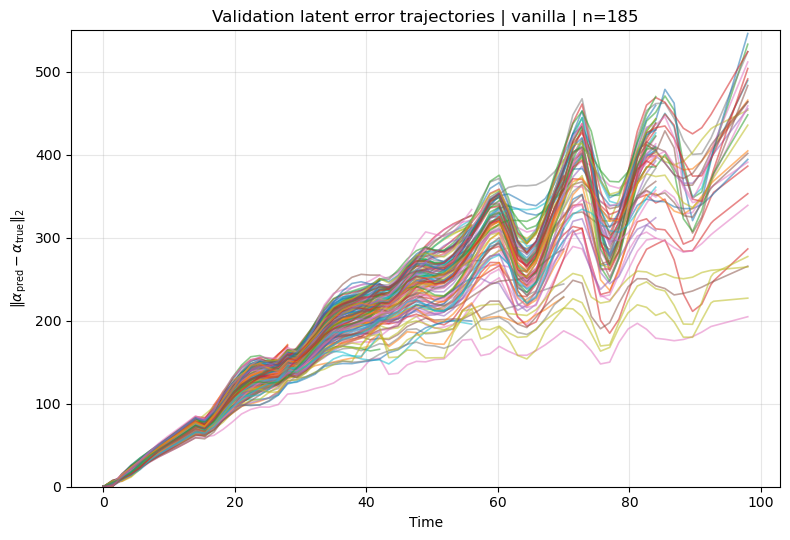

In [2]:
plot_all_val_latent_error_trajectories(
    zarr_path="FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    normalize_by_sqrt_r=False,
)

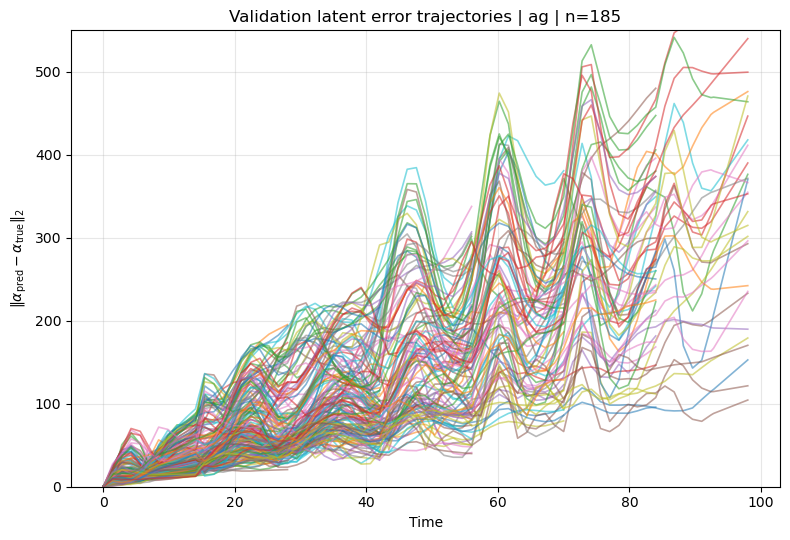

In [3]:
plot_all_val_latent_error_trajectories(
    zarr_path="FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    normalize_by_sqrt_r=False,
)

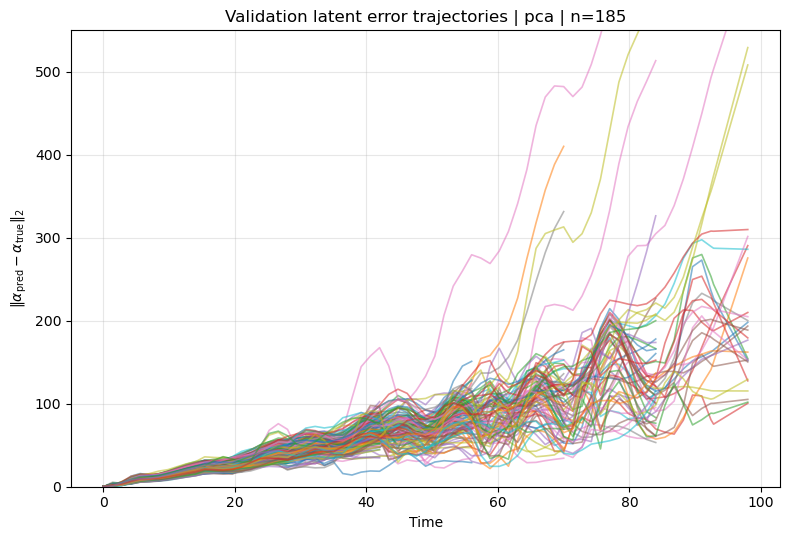

In [4]:
plot_all_val_latent_error_trajectories(
    zarr_path="FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    normalize_by_sqrt_r=False,
)

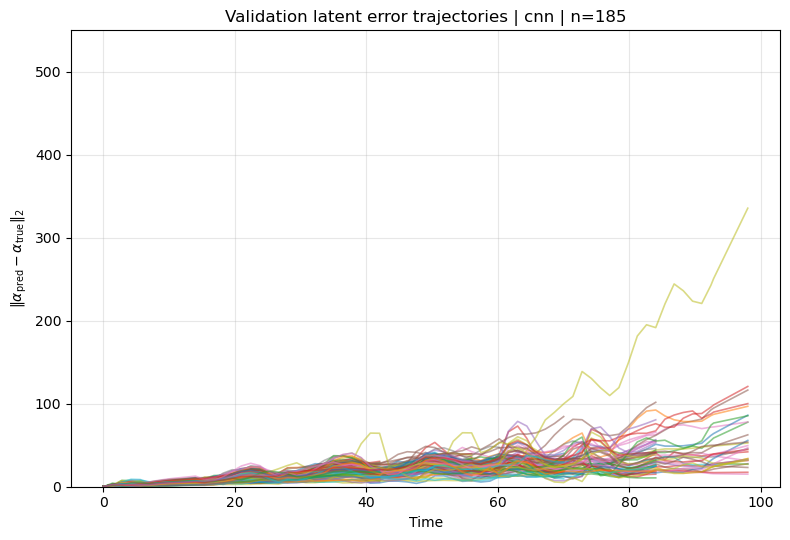

In [5]:
plot_all_val_latent_error_trajectories(
    zarr_path="FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    normalize_by_sqrt_r=False,
)

## Physical Space Norm Errors

In [23]:
import time
import numpy as np
import zarr
import matplotlib.pyplot as plt

def plot_all_val_physical_disp_error_trajectories_fast(
    rollout_zarr_path: str,
    zarr_disp_path: str = "displacements.zarr",
    snapshots_key: str = "snapshots",
    use_relative_time: bool = False,
    error_norm: str = "l2",
    normalize_by_sqrt_ndof: bool = False,
    linewidth: float = 1.2,
    alpha: float = 0.55,
    show_mean: bool = True,
    mean_linewidth: float = 3.0,
    print_every: int = 5,
):
    """
    Faster version: loads each sim's true snapshots in one batched slice instead of
    frame-by-frame zarr reads.
    """
    root = zarr.open_group(rollout_zarr_path, mode="r")
    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {rollout_zarr_path}")

    sims_grp = root["simulations"]
    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {rollout_zarr_path}/simulations")

    model_name = root.attrs.get("model_name", "model")

    g_disp = zarr.open_group(zarr_disp_path, mode="r")
    if snapshots_key not in g_disp:
        raise KeyError(f"Could not find '{snapshots_key}' in {zarr_disp_path}")
    snaps = g_disp[snapshots_key]

    g_design = zarr.open_group("Design_and_Metadata.zarr", mode="r")
    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index_all = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals_all = np.asarray(mgrp["time_vals"], dtype=np.float64)
    S = sim_index_all.shape[0]

    if snaps.ndim != 2:
        raise ValueError(f"Expected snapshots to be 2D, got shape {snaps.shape}")

    if snaps.shape[0] == S:      # (S, M)
        snapshot_major = True
        M = snaps.shape[1]
    elif snaps.shape[1] == S:    # (M, S)
        snapshot_major = False
        M = snaps.shape[0]
    else:
        raise ValueError(f"Snapshots shape {snaps.shape} doesn't match S={S} in either axis")

    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3, got M={M}")
    N = M // 3

    def load_true_u_nodes_for_sim_fast(sim_id: int):
        idx = np.where(sim_index_all == sim_id)[0]
        if idx.size == 0:
            raise ValueError(f"No snapshots found for sim_id={sim_id}")

        t_s = time_vals_all[idx]
        order = np.argsort(t_s)
        idx_sorted = idx[order]
        t_true = t_s[order]

        if snapshot_major:
            U_flat = np.asarray(snaps[idx_sorted, :], dtype=np.float64)   # (T, M)
        else:
            U_flat = np.asarray(snaps[:, idx_sorted], dtype=np.float64).T # (T, M)

        ux = U_flat[:, 0:N]
        uy = U_flat[:, N:2*N]
        uz = U_flat[:, 2*N:3*N]
        U_true = np.stack([ux, uy, uz], axis=2)  # (T, N, 3)

        return t_true, U_true

    plt.figure(figsize=(8, 5.5))

    interp_bank = []
    common_tau = np.linspace(0.0, 1.0, 300)
    ylabel = None

    n_sims = len(sim_keys)
    t0_wall = time.time()

    for i, sk in enumerate(sim_keys, start=1):
        g = sims_grp[sk]
        sim_id = int(g.attrs.get("sim_id", int(sk.split("_")[-1])))

        if (i == 1) or (print_every > 0 and (i % print_every == 0 or i == n_sims)):
            elapsed = time.time() - t0_wall
            sims_done = max(i - 1, 1) if i > 1 else 1
            rate = elapsed / sims_done
            sims_remaining = n_sims - (i - 1)
            eta_sec = rate * sims_remaining

            print(
                f"[{model_name}] sim {i}/{n_sims} "
                f"(current sim_id={sim_id}) | "
                f"elapsed={elapsed/60:.2f} min | "
                f"avg={rate:.2f} s/sim | "
                f"ETA={eta_sec/60:.2f} min"
            )

        if "u_pred_nodes" not in g:
            raise KeyError(f"{sk} missing 'u_pred_nodes'")

        u_pred = np.asarray(g["u_pred_nodes"], dtype=np.float64)

        if "t" in g:
            t = np.asarray(g["t"], dtype=np.float64)
        else:
            t = np.arange(u_pred.shape[0], dtype=np.float64)

        t_true, u_true = load_true_u_nodes_for_sim_fast(sim_id)

        if u_pred.shape != u_true.shape:
            raise ValueError(f"{sk}: u_pred shape {u_pred.shape} != u_true shape {u_true.shape}")
        if t.shape[0] != u_pred.shape[0]:
            raise ValueError(f"{sk}: t length {t.shape[0]} != u_pred length {u_pred.shape[0]}")

        err = u_pred - u_true

        if error_norm.lower() == "l2":
            y = np.linalg.norm(err.reshape(err.shape[0], -1), axis=1)
            if normalize_by_sqrt_ndof:
                ndof = err.shape[1] * err.shape[2]
                y = y / np.sqrt(ndof)
            ylabel = r"$\|u_{\mathrm{pred}}-u_{\mathrm{true}}\|_2$"
            if normalize_by_sqrt_ndof:
                ylabel += r" $/ \sqrt{N_{\mathrm{dof}}}$"
        elif error_norm.lower() == "rmse":
            y = np.sqrt(np.mean(err**2, axis=(1, 2)))
            ylabel = "Displacement RMSE"
        elif error_norm.lower() == "mae":
            y = np.mean(np.abs(err), axis=(1, 2))
            ylabel = "Displacement MAE"
        else:
            raise ValueError("error_norm must be one of {'l2','rmse','mae'}")

        if use_relative_time:
            if len(t) == 1 or (t[-1] - t[0]) <= 0:
                x = np.zeros_like(t)
            else:
                x = (t - t[0]) / (t[-1] - t[0])

            plt.plot(x, y, linewidth=linewidth, alpha=alpha)

            x_unique, idx_unique = np.unique(x, return_index=True)
            y_unique = y[idx_unique]
            if x_unique.size >= 2:
                interp_bank.append(np.interp(common_tau, x_unique, y_unique))
        else:
            plt.plot(t, y, linewidth=linewidth, alpha=alpha)

    if show_mean and use_relative_time and len(interp_bank) > 0:
        mean_curve = np.mean(np.vstack(interp_bank), axis=0)
        plt.plot(common_tau, mean_curve, linewidth=mean_linewidth, label="Mean trajectory")

    total_elapsed = time.time() - t0_wall
    print(f"[{model_name}] done | total elapsed = {total_elapsed/60:.2f} min")

    plt.xlabel("Normalized rollout progress" if use_relative_time else "Time")
    plt.ylabel(ylabel)
    plt.title(f"Validation physical displacement error trajectories | {model_name} | n={len(sim_keys)}")

    if show_mean and use_relative_time and len(interp_bank) > 0:
        plt.legend()

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

[vanilla] sim 1/185 (current sim_id=4) | elapsed=0.00 min | avg=0.00 s/sim | ETA=0.00 min
[vanilla] sim 50/185 (current sim_id=235) | elapsed=0.58 min | avg=0.70 s/sim | ETA=1.60 min
[vanilla] sim 100/185 (current sim_id=520) | elapsed=1.16 min | avg=0.70 s/sim | ETA=1.00 min
[vanilla] sim 150/185 (current sim_id=769) | elapsed=1.72 min | avg=0.69 s/sim | ETA=0.42 min
[vanilla] sim 185/185 (current sim_id=924) | elapsed=2.04 min | avg=0.67 s/sim | ETA=0.01 min
[vanilla] done | total elapsed = 2.05 min


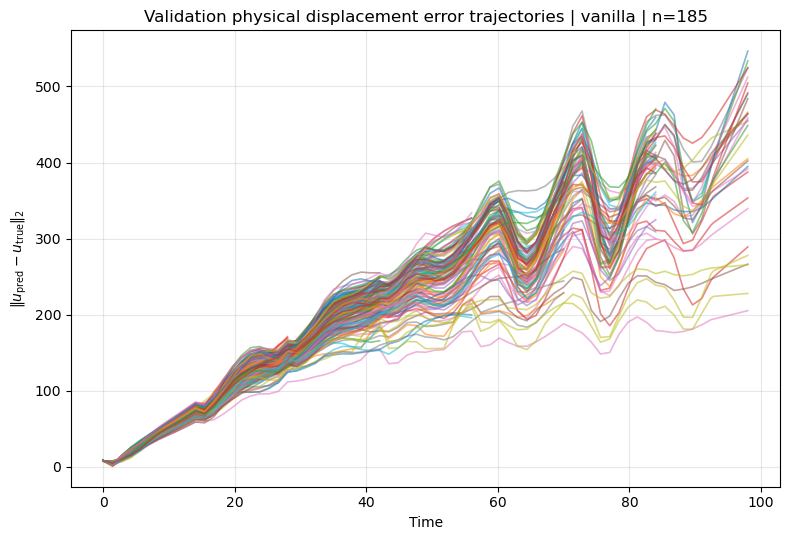

In [27]:
plot_all_val_physical_disp_error_trajectories_fast(
    rollout_zarr_path="FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    print_every=50,
)

[ag] sim 1/185 (current sim_id=4) | elapsed=0.00 min | avg=0.02 s/sim | ETA=0.05 min
[ag] sim 50/185 (current sim_id=235) | elapsed=0.59 min | avg=0.72 s/sim | ETA=1.64 min
[ag] sim 100/185 (current sim_id=520) | elapsed=1.20 min | avg=0.73 s/sim | ETA=1.04 min
[ag] sim 150/185 (current sim_id=769) | elapsed=1.77 min | avg=0.71 s/sim | ETA=0.43 min
[ag] sim 185/185 (current sim_id=924) | elapsed=2.11 min | avg=0.69 s/sim | ETA=0.01 min
[ag] done | total elapsed = 2.12 min


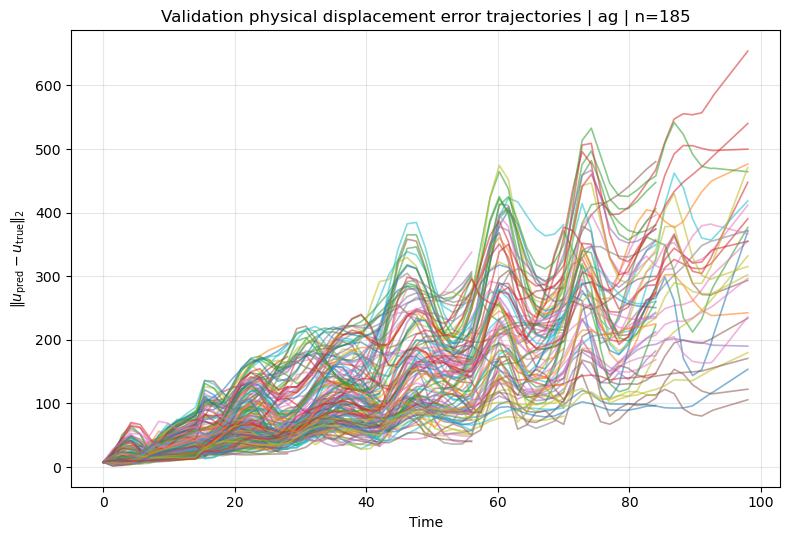

In [28]:
plot_all_val_physical_disp_error_trajectories_fast(
    rollout_zarr_path="FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    print_every=50,
)

[pca] sim 1/185 (current sim_id=4) | elapsed=0.00 min | avg=0.00 s/sim | ETA=0.00 min
[pca] sim 50/185 (current sim_id=235) | elapsed=0.60 min | avg=0.73 s/sim | ETA=1.66 min
[pca] sim 100/185 (current sim_id=520) | elapsed=1.19 min | avg=0.72 s/sim | ETA=1.04 min
[pca] sim 150/185 (current sim_id=769) | elapsed=1.76 min | avg=0.71 s/sim | ETA=0.42 min
[pca] sim 185/185 (current sim_id=924) | elapsed=2.09 min | avg=0.68 s/sim | ETA=0.01 min
[pca] done | total elapsed = 2.10 min


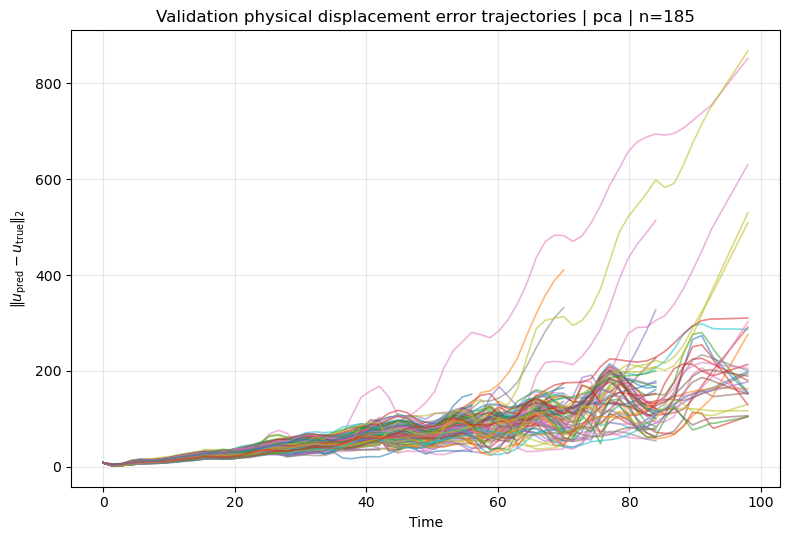

In [29]:
plot_all_val_physical_disp_error_trajectories_fast(
    rollout_zarr_path="FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    print_every=50,
)

[cnn] sim 1/185 (current sim_id=4) | elapsed=0.00 min | avg=0.00 s/sim | ETA=0.00 min
[cnn] sim 50/185 (current sim_id=235) | elapsed=0.59 min | avg=0.72 s/sim | ETA=1.64 min
[cnn] sim 100/185 (current sim_id=520) | elapsed=1.19 min | avg=0.72 s/sim | ETA=1.04 min
[cnn] sim 150/185 (current sim_id=769) | elapsed=1.76 min | avg=0.71 s/sim | ETA=0.43 min
[cnn] sim 185/185 (current sim_id=924) | elapsed=2.10 min | avg=0.68 s/sim | ETA=0.01 min
[cnn] done | total elapsed = 2.11 min


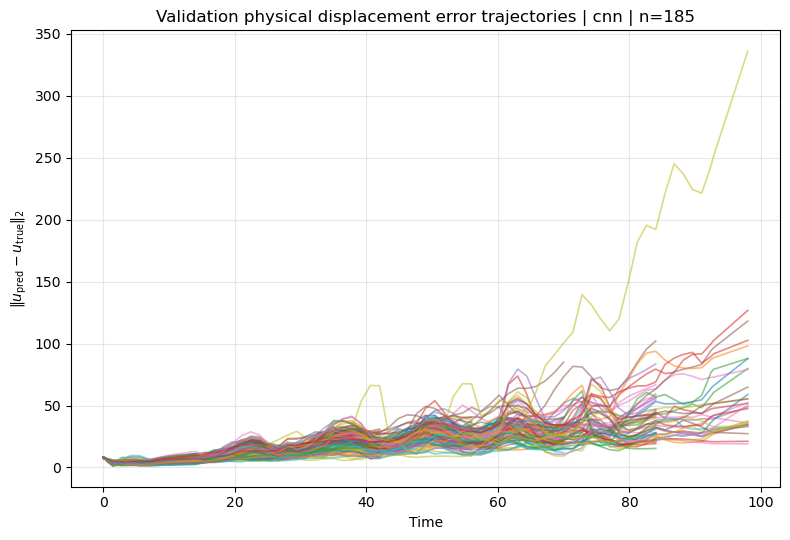

In [30]:
plot_all_val_physical_disp_error_trajectories_fast(
    rollout_zarr_path="FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr",
    use_relative_time=False,
    error_norm="l2",
    print_every=50,
)

## Store all the RMSEs in a Zarr

In [31]:
import numpy as np

def compute_surface_disp_rmse_trajectory(
    u_pred: np.ndarray,
    u_true: np.ndarray,
) -> np.ndarray:
    """
    Compute per-time surface displacement RMSE.

    Parameters
    ----------
    u_pred, u_true : np.ndarray
        Shape (T, N, 3)

    Returns
    -------
    rmse_t : np.ndarray
        Shape (T,), where
        rmse_t[k] = sqrt( mean_i ||u_pred[k,i,:] - u_true[k,i,:]||_2^2 )
    """
    u_pred = np.asarray(u_pred, dtype=np.float64)
    u_true = np.asarray(u_true, dtype=np.float64)

    if u_pred.shape != u_true.shape:
        raise ValueError(f"Shape mismatch: u_pred {u_pred.shape} vs u_true {u_true.shape}")
    if u_pred.ndim != 3 or u_pred.shape[2] != 3:
        raise ValueError(f"Expected shape (T,N,3), got {u_pred.shape}")

    err = u_pred - u_true                  # (T,N,3)
    err_sq = np.sum(err**2, axis=2)        # (T,N), squared vector norm at each node
    rmse_t = np.sqrt(np.mean(err_sq, axis=1))  # (T,)
    return rmse_t.astype(np.float32)

In [32]:
import time
import numpy as np
import zarr

def add_surface_disp_rmse_to_rollout_zarr(
    rollout_zarr_path: str,
    zarr_disp_path: str = "displacements.zarr",
    snapshots_key: str = "snapshots",
    print_every: int = 5,
    overwrite: bool = True,
):
    """
    Augment an existing rollout zarr by computing and saving:
      - u_true_nodes            : (T,N,3)
      - disp_err_pointwise_rmse : (T,)

    for every simulation group.

    This avoids having to re-read the master displacement zarr later for plotting.
    """
    root = zarr.open_group(rollout_zarr_path, mode="a")
    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {rollout_zarr_path}")

    sims_grp = root["simulations"]
    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {rollout_zarr_path}/simulations")

    model_name = root.attrs.get("model_name", "model")

    # --- open truth data ---
    g_disp = zarr.open_group(zarr_disp_path, mode="r")
    if snapshots_key not in g_disp:
        raise KeyError(f"Could not find '{snapshots_key}' in {zarr_disp_path}")
    snaps = g_disp[snapshots_key]

    g_design = zarr.open_group("Design_and_Metadata.zarr", mode="r")
    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index_all = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals_all = np.asarray(mgrp["time_vals"], dtype=np.float64)
    S = sim_index_all.shape[0]

    if snaps.ndim != 2:
        raise ValueError(f"Expected snapshots to be 2D, got shape {snaps.shape}")

    # infer snapshot layout once
    if snaps.shape[0] == S:      # (S, M)
        snapshot_major = True
        M = snaps.shape[1]
    elif snaps.shape[1] == S:    # (M, S)
        snapshot_major = False
        M = snaps.shape[0]
    else:
        raise ValueError(f"Snapshots shape {snaps.shape} doesn't match S={S} in either axis")

    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3, got M={M}")
    N = M // 3

    def load_true_u_nodes_for_sim_fast(sim_id: int):
        idx = np.where(sim_index_all == sim_id)[0]
        if idx.size == 0:
            raise ValueError(f"No snapshots found for sim_id={sim_id}")

        t_s = time_vals_all[idx]
        order = np.argsort(t_s)
        idx_sorted = idx[order]
        t_true = t_s[order]

        if snapshot_major:
            U_flat = np.asarray(snaps[idx_sorted, :], dtype=np.float64)   # (T,M)
        else:
            U_flat = np.asarray(snaps[:, idx_sorted], dtype=np.float64).T # (T,M)

        ux = U_flat[:, 0:N]
        uy = U_flat[:, N:2*N]
        uz = U_flat[:, 2*N:3*N]
        U_true = np.stack([ux, uy, uz], axis=2)  # (T,N,3)

        return t_true, U_true.astype(np.float32)

    def _write_array(grp, name, arr):
        arr = np.asarray(arr)
        if name in grp and overwrite:
            del grp[name]
        try:
            grp.create_dataset(name, data=arr, shape=arr.shape, dtype=arr.dtype, overwrite=overwrite)
        except TypeError:
            try:
                grp.create_dataset(name, data=arr, overwrite=overwrite)
            except Exception:
                grp.array(name, arr, overwrite=overwrite)

    n_sims = len(sim_keys)
    t0 = time.time()

    for i, sk in enumerate(sim_keys, start=1):
        sim_grp = sims_grp[sk]
        sim_id = int(sim_grp.attrs.get("sim_id", int(sk.split("_")[-1])))

        if (i == 1) or (print_every > 0 and (i % print_every == 0 or i == n_sims)):
            elapsed = time.time() - t0
            sims_done = max(i - 1, 1) if i > 1 else 1
            rate = elapsed / sims_done
            eta = rate * (n_sims - (i - 1))
            print(
                f"[{model_name}] augment sim {i}/{n_sims} "
                f"(sim_id={sim_id}) | elapsed={elapsed/60:.2f} min | "
                f"avg={rate:.2f} s/sim | ETA={eta/60:.2f} min"
            )

        if "u_pred_nodes" not in sim_grp:
            raise KeyError(f"{sk} missing 'u_pred_nodes'")

        u_pred = np.asarray(sim_grp["u_pred_nodes"], dtype=np.float32)
        _, u_true = load_true_u_nodes_for_sim_fast(sim_id)

        if u_pred.shape != u_true.shape:
            raise ValueError(f"{sk}: u_pred shape {u_pred.shape} != u_true shape {u_true.shape}")

        rmse_t = compute_surface_disp_rmse_trajectory(u_pred, u_true)

        _write_array(sim_grp, "u_true_nodes", u_true)
        _write_array(sim_grp, "disp_err_pointwise_rmse", rmse_t)

        sim_grp.attrs["final_disp_err_pointwise_rmse"] = float(rmse_t[-1])
        sim_grp.attrs["max_disp_err_pointwise_rmse"] = float(np.max(rmse_t))

    total_elapsed = time.time() - t0
    root.attrs["has_u_true_nodes"] = True
    root.attrs["has_disp_err_pointwise_rmse"] = True

    print(f"[{model_name}] done augmenting zarr | total elapsed = {total_elapsed/60:.2f} min")

In [33]:
add_surface_disp_rmse_to_rollout_zarr("FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr")
add_surface_disp_rmse_to_rollout_zarr("FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr")
add_surface_disp_rmse_to_rollout_zarr("FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr")
add_surface_disp_rmse_to_rollout_zarr("FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr")

[vanilla] augment sim 1/185 (sim_id=4) | elapsed=0.00 min | avg=0.00 s/sim | ETA=0.00 min


C:\Users\jml2414\AppData\Local\Temp\ipykernel_34128\1472411792.py:88: ZarrDeprecationWarning: Use Group.create_array instead.
  grp.create_dataset(name, data=arr, shape=arr.shape, dtype=arr.dtype, overwrite=overwrite)


[vanilla] augment sim 5/185 (sim_id=31) | elapsed=0.05 min | avg=0.76 s/sim | ETA=2.29 min
[vanilla] augment sim 10/185 (sim_id=50) | elapsed=0.11 min | avg=0.75 s/sim | ETA=2.20 min
[vanilla] augment sim 15/185 (sim_id=74) | elapsed=0.17 min | avg=0.74 s/sim | ETA=2.10 min
[vanilla] augment sim 20/185 (sim_id=90) | elapsed=0.23 min | avg=0.74 s/sim | ETA=2.05 min
[vanilla] augment sim 25/185 (sim_id=131) | elapsed=0.30 min | avg=0.74 s/sim | ETA=1.99 min
[vanilla] augment sim 30/185 (sim_id=161) | elapsed=0.36 min | avg=0.74 s/sim | ETA=1.93 min
[vanilla] augment sim 35/185 (sim_id=171) | elapsed=0.42 min | avg=0.74 s/sim | ETA=1.87 min
[vanilla] augment sim 40/185 (sim_id=188) | elapsed=0.48 min | avg=0.74 s/sim | ETA=1.80 min
[vanilla] augment sim 45/185 (sim_id=209) | elapsed=0.54 min | avg=0.74 s/sim | ETA=1.74 min
[vanilla] augment sim 50/185 (sim_id=235) | elapsed=0.61 min | avg=0.74 s/sim | ETA=1.68 min
[vanilla] augment sim 55/185 (sim_id=267) | elapsed=0.67 min | avg=0.74 s/s

## Plot the RMSE across the Models

In [6]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

def plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path: str,
    use_relative_time: bool = False,
    linewidth: float = 1.2,
    alpha: float = 0.55,
    show_mean: bool = True,
    mean_linewidth: float = 3.0,
):
    """
    Plot saved surface displacement RMSE trajectories for all validation sims.

    Expects each sim group to contain:
      - t
      - disp_err_pointwise_rmse
    """
    root = zarr.open_group(rollout_zarr_path, mode="r")
    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {rollout_zarr_path}")

    sims_grp = root["simulations"]
    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {rollout_zarr_path}/simulations")

    model_name = root.attrs.get("model_name", "model")

    plt.figure(figsize=(8, 5.5))

    interp_bank = []
    common_tau = np.linspace(0.0, 1.0, 300)

    for sk in sim_keys:
        g = sims_grp[sk]

        if "disp_err_pointwise_rmse" not in g:
            raise KeyError(
                f"{sk} missing 'disp_err_pointwise_rmse'. "
                f"Run add_surface_disp_rmse_to_rollout_zarr(...) first."
            )

        y = np.asarray(g["disp_err_pointwise_rmse"], dtype=np.float64)

        if "t" in g:
            t = np.asarray(g["t"], dtype=np.float64)
        else:
            t = np.arange(y.shape[0], dtype=np.float64)

        if t.shape[0] != y.shape[0]:
            raise ValueError(f"{sk}: t length {t.shape[0]} != rmse length {y.shape[0]}")

        if use_relative_time:
            if len(t) == 1 or (t[-1] - t[0]) <= 0:
                x = np.zeros_like(t)
            else:
                x = (t - t[0]) / (t[-1] - t[0])

            plt.plot(x, y, linewidth=linewidth, alpha=alpha)

            x_unique, idx_unique = np.unique(x, return_index=True)
            y_unique = y[idx_unique]
            if x_unique.size >= 2:
                interp_bank.append(np.interp(common_tau, x_unique, y_unique))
        else:
            plt.plot(t, y, linewidth=linewidth, alpha=alpha)

    if show_mean and use_relative_time and len(interp_bank) > 0:
        mean_curve = np.mean(np.vstack(interp_bank), axis=0)
        plt.plot(common_tau, mean_curve, linewidth=mean_linewidth, label="Mean trajectory")

    plt.xlabel("Normalized rollout progress" if use_relative_time else "Time [days]")
    plt.ylabel("Surface displacement RMSE [mm]")
    plt.title(f"Validation surface displacement RMSE trajectories | {model_name} | n={len(sim_keys)}")

    if show_mean and use_relative_time and len(interp_bank) > 0:
        plt.legend()

    plt.grid(alpha=0.3)
    plt.ylim([0,10])
    plt.tight_layout()
    plt.show()

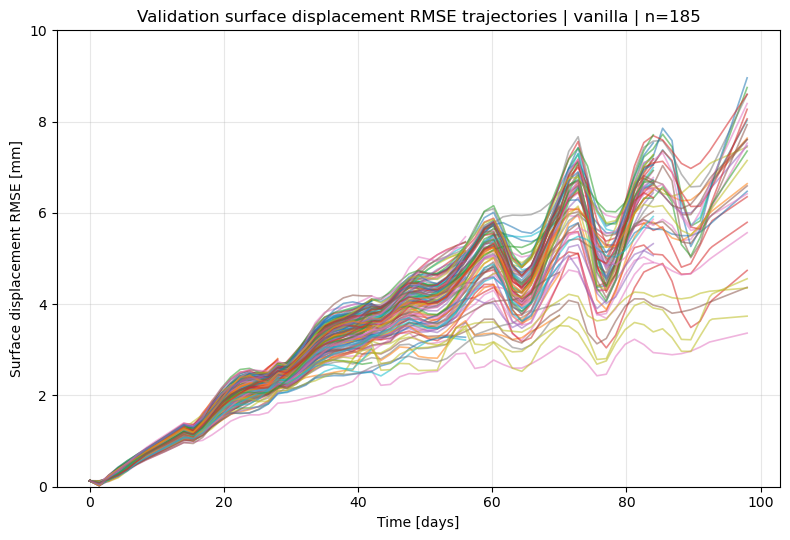

In [7]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr",
    use_relative_time=False,
)

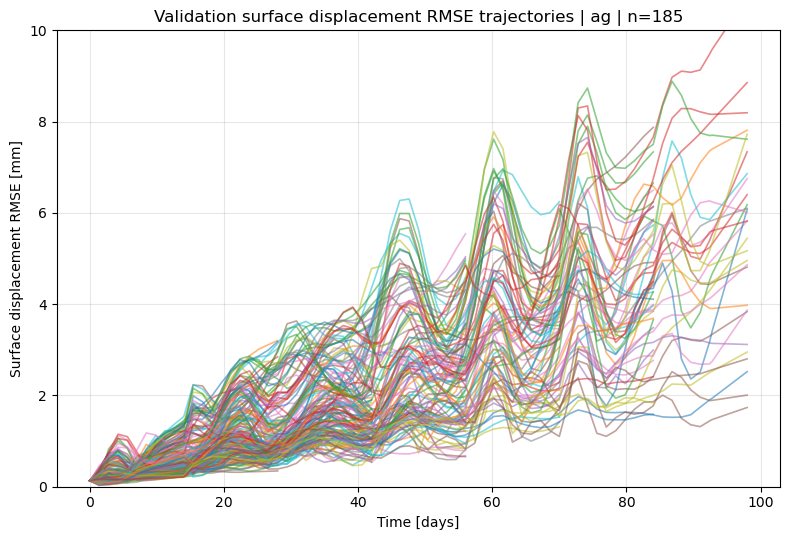

In [8]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr",
    use_relative_time=False,
)

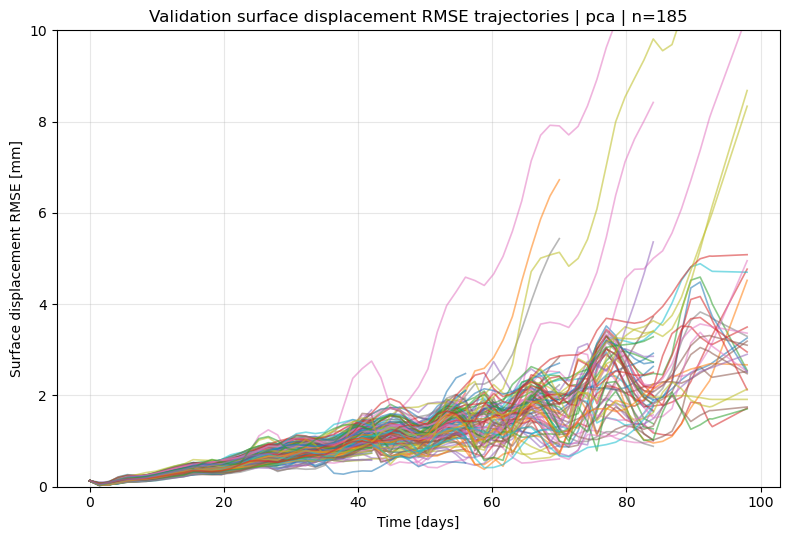

In [9]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr",
    use_relative_time=False,
)

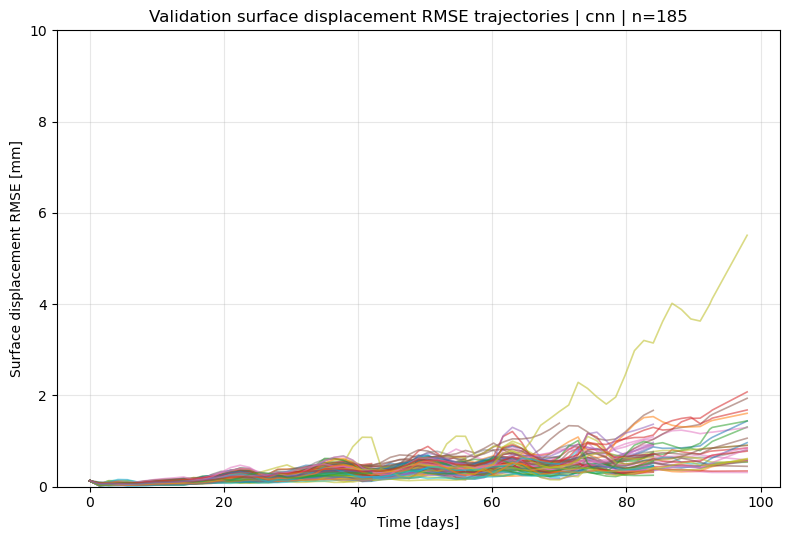

In [10]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr",
    use_relative_time=False,
)

## Add the Confidence bounds

In [1]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

def plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path: str,
    use_relative_time: bool = False,
    linewidth: float = 0.9,
    alpha: float = 0.18,
    show_all_curves: bool = True,
    summary_linewidth: float = 3.0,
    band_alpha: float = 0.22,
    n_interp: int = 300,
    use_seaborn_style: bool = True,
    ylim: tuple[float, float] | None = (0, 10),

    # NEW: highlighted simulation
    highlight_sim_id: int | None = None,
    highlight_color: str = "lightblue",
    highlight_linewidth: float = 2.4,
    highlight_alpha: float = 1.0,
    highlight_label: str = "Selected sim",

    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot saved surface displacement RMSE trajectories for all validation sims,
    with median and 10th-90th percentile summary.

    Expects each sim group to contain:
      - t
      - disp_err_pointwise_rmse

    Parameters
    ----------
    rollout_zarr_path : str
        Path to rollout zarr.
    use_relative_time : bool
        If True, normalize each trajectory's time to [0, 1] before aggregating.
    linewidth : float
        Line width for background individual curves.
    alpha : float
        Alpha for background individual curves.
    show_all_curves : bool
        Whether to plot all individual trajectories in the background.
    summary_linewidth : float
        Line width for the median trajectory.
    band_alpha : float
        Alpha for the 10th-90th percentile shaded band.
    n_interp : int
        Number of interpolation points for the common grid.
    use_seaborn_style : bool
        If True, use a seaborn-like whitegrid style.
    ylim : tuple or None
        y-axis limits. Set to None for automatic limits.
    highlight_sim_id : int or None
        If provided, plot this simulation's RMSE trajectory in a highlighted color.
    highlight_color : str
        Color for the highlighted simulation trajectory.
    highlight_linewidth : float
        Line width for the highlighted simulation trajectory.
    highlight_alpha : float
        Alpha for the highlighted simulation trajectory.
    highlight_label : str
        Legend label for the highlighted simulation trajectory.
    """
    if use_seaborn_style:
        try:
            plt.style.use("seaborn-v0_8-whitegrid")
        except Exception:
            plt.style.use("default")

    root = zarr.open_group(rollout_zarr_path, mode="r")
    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {rollout_zarr_path}")

    sims_grp = root["simulations"]
    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {rollout_zarr_path}/simulations")

    model_name = root.attrs.get("model_name", "model")

    fig, ax = plt.subplots(figsize=(8.4, 5.6))

    # First pass: collect trajectories
    traj_data = []
    all_t_min = []
    all_t_max = []

    for sk in sim_keys:
        g = sims_grp[sk]

        if "disp_err_pointwise_rmse" not in g:
            raise KeyError(
                f"{sk} missing 'disp_err_pointwise_rmse'. "
                f"Run add_surface_disp_rmse_to_rollout_zarr(...) first."
            )

        y = np.asarray(g["disp_err_pointwise_rmse"], dtype=np.float64)

        if "t" in g:
            t = np.asarray(g["t"], dtype=np.float64)
        else:
            t = np.arange(y.shape[0], dtype=np.float64)

        if t.shape[0] != y.shape[0]:
            raise ValueError(f"{sk}: t length {t.shape[0]} != rmse length {y.shape[0]}")

        if use_relative_time:
            if len(t) == 1 or (t[-1] - t[0]) <= 0:
                x = np.zeros_like(t)
            else:
                x = (t - t[0]) / (t[-1] - t[0])
        else:
            x = t
            all_t_min.append(np.min(t))
            all_t_max.append(np.max(t))

        traj_data.append((sk, x, y))

    # Common interpolation grid
    if use_relative_time:
        x_common = np.linspace(0.0, 1.0, n_interp)
    else:
        x_common = np.linspace(min(all_t_min), max(all_t_max), n_interp)

    interp_bank = []
    highlighted_found = False

    # Plot background curves + interpolate onto common grid
    for sk, x, y in traj_data:
        x_unique, idx_unique = np.unique(x, return_index=True)
        y_unique = y[idx_unique]

        if x_unique.size < 2:
            continue

        # Try to infer sim_id from group name
        is_highlight = False
        if highlight_sim_id is not None:
            try:
                sim_id_this = int(sk)
                is_highlight = (sim_id_this == highlight_sim_id)
            except ValueError:
                # fallback: check group attrs if present
                g = sims_grp[sk]
                sim_id_attr = g.attrs.get("sim_id", None)
                if sim_id_attr is not None:
                    is_highlight = (int(sim_id_attr) == int(highlight_sim_id))

        if show_all_curves and not is_highlight:
            ax.plot(
                x_unique, y_unique,
                linewidth=linewidth,
                alpha=alpha,
            )

        if is_highlight:
            ax.plot(
                x_unique, y_unique,
                color=highlight_color,
                linewidth=highlight_linewidth,
                alpha=highlight_alpha,
                label=f"{highlight_label} ({highlight_sim_id})",
                zorder=5,
            )
            highlighted_found = True

        # Interpolate only over the support of this trajectory
        y_interp = np.interp(x_common, x_unique, y_unique, left=np.nan, right=np.nan)
        interp_bank.append(y_interp)

    if len(interp_bank) == 0:
        raise ValueError("Not enough valid trajectories to compute summary statistics.")

    Y = np.vstack(interp_bank)  # shape: [n_sims, n_interp]

    # Summary statistics ignoring NaNs
    y_p10 = np.nanpercentile(Y, 10, axis=0)
    y_med = np.nanpercentile(Y, 50, axis=0)
    y_p90 = np.nanpercentile(Y, 90, axis=0)

    # Percentile band
    ax.fill_between(
        x_common, y_p10, y_p90,
        color="tab:red",
        alpha=band_alpha,
        label="10th–90th percentile"
    )

    # Median curve
    ax.plot(
        x_common, y_med,
        color="black",
        linewidth=summary_linewidth,
        label="Median"
    )

    if highlight_sim_id is not None and not highlighted_found:
        print(f"[warn] highlight_sim_id={highlight_sim_id} was not found in the zarr groups.")

    ax.set_title(
        f"Validation surface displacement RMSE trajectories | "
        f"{model_name} | n={len(sim_keys)}"
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    print(f"Final median RMSE = {y_med[-1]:.6f}")
    print(f"Second-to-last median RMSE = {y_med[-2]:.6f}")
    print(f"Last few median values = {y_med[-10:]}")
    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")

    plt.show()

In [2]:
# ax.tick_params(
    #     axis='both',
    #     which='both',
    #     labelbottom=False,
    #     labelleft=False
    # )

    # ax.tick_params(
    #     axis='both',
    #     which='both',
    #     labelbottom=False,
    #     labelleft=False,
    #     labeltop=False,
    #     labelright=False
    # )

Final median RMSE = 7.400182
Second-to-last median RMSE = 7.348166
Last few median values = [6.72171182 6.80160928 6.88150675 6.96140421 7.04130167 7.12119913
 7.2010966  7.28099406 7.34816622 7.40018153]


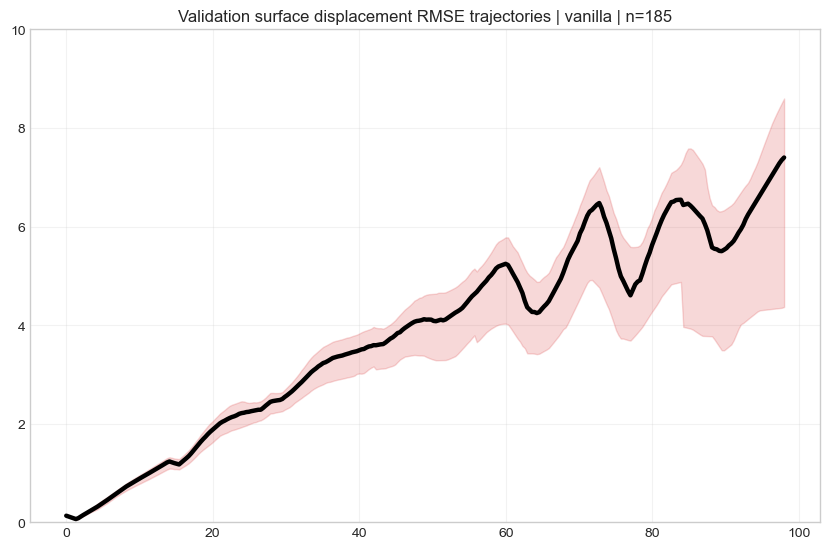

In [3]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr",
    use_relative_time=False,
    show_all_curves=False,
    alpha=0.12,
    linewidth=0.9,
    summary_linewidth=3.2,
    band_alpha=0.18,
    ylim=(0, 10),
    save_dpi=600,

)

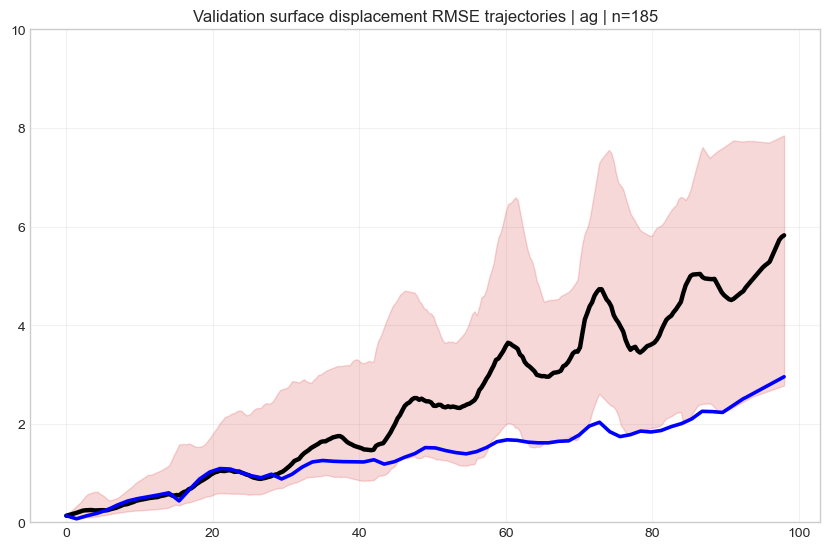

In [5]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr",
    use_relative_time=False,
    show_all_curves=False,
    alpha=0.12,
    linewidth=0.9,
    summary_linewidth=3.2,
    band_alpha=0.18,
    ylim=(0, 10),
    save_path="Model_B_disp_rmse_summary.png",
    save_dpi=600,
    highlight_sim_id=804,
    highlight_color="blue",
    highlight_linewidth=2.6,
)

Final median RMSE = 3.145210
Second-to-last median RMSE = 3.133915
Last few median values = [3.23631244 3.21298919 3.18838906 3.1292571  3.10604717 3.10593148
 3.11132443 3.12261967 3.13391491 3.14521015]


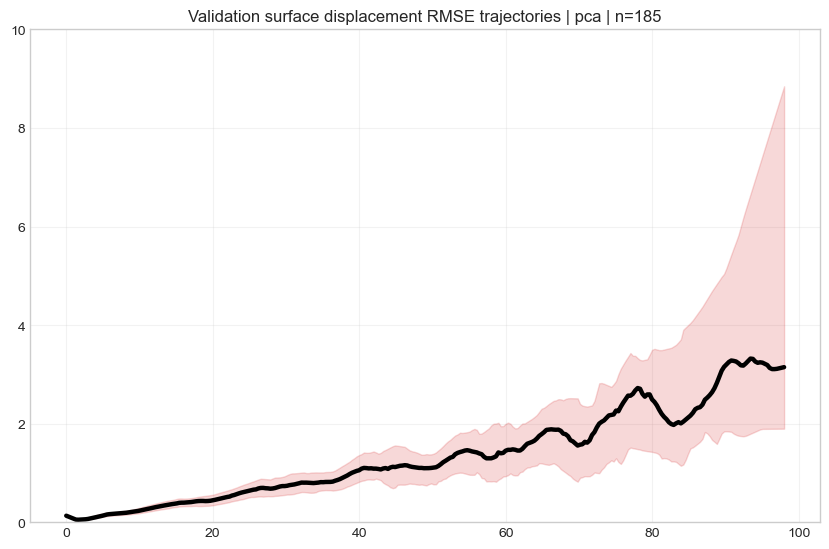

In [4]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr",
    use_relative_time=False,
    show_all_curves=False,
    alpha=0.12,
    linewidth=0.9,
    summary_linewidth=3.2,
    band_alpha=0.18,
    ylim=(0, 10),
    save_path="Model_C_disp_rmse_summary.png",
    save_dpi=600,
)

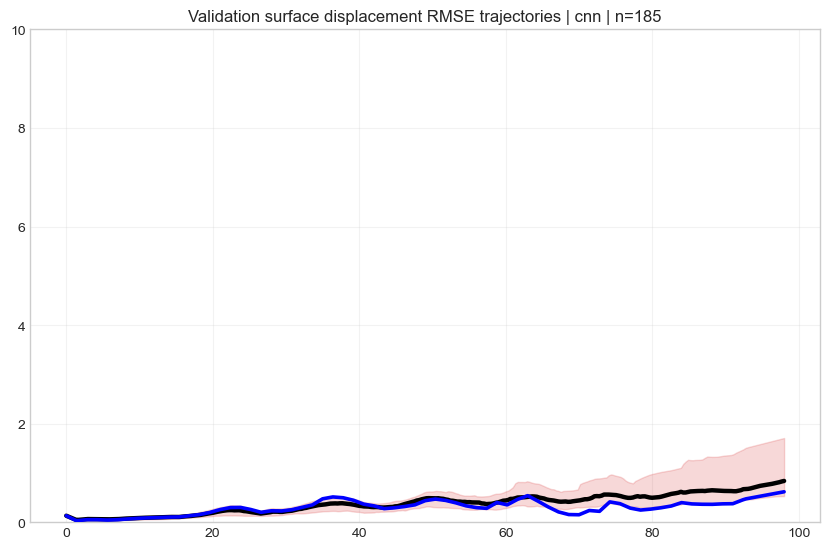

In [7]:
plot_all_val_surface_disp_rmse_trajectories(
    rollout_zarr_path="FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr",
    use_relative_time=False,
    show_all_curves=False,
    alpha=0.12,
    linewidth=0.9,
    summary_linewidth=3.2,
    band_alpha=0.18,
    ylim=(0, 10),
    save_path="Model_D_disp_rmse_summary.png",
    save_dpi=600,
    highlight_sim_id=804,
    highlight_color="blue",
    highlight_linewidth=2.6,
)

In [6]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

def plot_final_val_surface_disp_rmse_histogram(
    rollout_zarr_path: str,
    bins: int = 25,
    density: bool = False,
    use_seaborn_style: bool = True,
    figsize: tuple[float, float] = (7.2, 5.0),
    alpha: float = 0.8,
    edgecolor: str = "black",
    linewidth: float = 0.8,
    color: str = "tab:blue",
    show_mean: bool = True,
    show_median: bool = True,
    mean_color: str = "tab:red",
    median_color: str = "black",
    ref_value: float | None = None,
    ref_label: str = "Reference",
    ref_color: str = "tab:green",
    xlim: tuple[float, float] | None = None,

    # NEW
    support_time: float | None = None,
    infer_support_time_from_global_max_t: bool = True,
    atol: float = 1e-10,

    title_fontsize: float = 42,
    label_fontsize: float = 36,
    tick_fontsize: float = 24,
    legend_fontsize: float = 22,

    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot histogram of surface displacement RMSE across validation rollouts,
    evaluated only for simulations that have support at a specified time.

    Behavior
    --------
    - If support_time is provided, only sims with t_min <= support_time <= t_max
      are included, and RMSE is evaluated at support_time by interpolation.
    - If support_time is None and infer_support_time_from_global_max_t is True,
      use the global maximum terminal time across all simulations.
      This matches the rightmost point of the trajectory plot when
      use_relative_time=False.
    - If neither applies, falls back to using each sim's own final RMSE.
    """
    if use_seaborn_style:
        try:
            plt.style.use("seaborn-v0_8-whitegrid")
        except Exception:
            plt.style.use("default")

    root = zarr.open_group(rollout_zarr_path, mode="r")
    if "simulations" not in root:
        raise KeyError(f"No 'simulations' group found in {rollout_zarr_path}")

    sims_grp = root["simulations"]
    sim_keys = sorted(list(sims_grp.group_keys()))
    if len(sim_keys) == 0:
        raise ValueError(f"No simulation groups found in {rollout_zarr_path}/simulations")

    model_name = root.attrs.get("model_name", "model")

    # ------------------------------------------------------------
    # First pass: determine target support time if requested
    # ------------------------------------------------------------
    target_time = support_time

    if target_time is None and infer_support_time_from_global_max_t:
        all_t_max = []

        for sk in sim_keys:
            g = sims_grp[sk]
            if "disp_err_pointwise_rmse" not in g:
                continue

            y = np.asarray(g["disp_err_pointwise_rmse"], dtype=np.float64).squeeze()
            if y.size == 0:
                continue

            if "t" in g:
                t = np.asarray(g["t"], dtype=np.float64).squeeze()
            else:
                t = np.arange(y.shape[0], dtype=np.float64)

            if t.size == y.size and t.size > 0:
                all_t_max.append(np.max(t))

        if len(all_t_max) == 0:
            raise ValueError("Could not infer a global support time from simulation time arrays.")

        target_time = float(np.max(all_t_max))

    # ------------------------------------------------------------
    # Second pass: collect values
    # ------------------------------------------------------------
    rmse_vals = []
    used_sim_keys = []
    skipped_no_support = []
    skipped_invalid = []

    for sk in sim_keys:
        g = sims_grp[sk]

        if "disp_err_pointwise_rmse" not in g:
            raise KeyError(
                f"{sk} missing 'disp_err_pointwise_rmse'. "
                f"Run add_surface_disp_rmse_to_rollout_zarr(...) first."
            )

        y = np.asarray(g["disp_err_pointwise_rmse"], dtype=np.float64).squeeze()
        if y.size == 0:
            skipped_invalid.append(sk)
            continue

        if "t" in g:
            t = np.asarray(g["t"], dtype=np.float64).squeeze()
        else:
            t = np.arange(y.shape[0], dtype=np.float64)

        if t.size != y.size or t.size == 0:
            skipped_invalid.append(sk)
            continue

        # Remove duplicate x values in case they exist
        t_unique, idx_unique = np.unique(t, return_index=True)
        y_unique = y[idx_unique]

        if t_unique.size == 0:
            skipped_invalid.append(sk)
            continue

        if target_time is None:
            # Fallback behavior: use each sim's own terminal value
            val = y_unique[-1]
            if np.isfinite(val):
                rmse_vals.append(val)
                used_sim_keys.append(sk)
            else:
                skipped_invalid.append(sk)
            continue

        # Keep only sims with support at target_time
        t_min = t_unique[0]
        t_max = t_unique[-1]

        if (target_time < t_min - atol) or (target_time > t_max + atol):
            skipped_no_support.append(sk)
            continue

        # Interpolate at target_time
        val = np.interp(target_time, t_unique, y_unique)

        if np.isfinite(val):
            rmse_vals.append(val)
            used_sim_keys.append(sk)
        else:
            skipped_invalid.append(sk)

    if len(rmse_vals) == 0:
        raise ValueError("No valid RMSE values found for the requested support time.")

    rmse_vals = np.asarray(rmse_vals, dtype=np.float64)

    mean_val = np.mean(rmse_vals)
    median_val = np.median(rmse_vals)
    p10 = np.percentile(rmse_vals, 10)
    p90 = np.percentile(rmse_vals, 90)
    std_val = np.std(rmse_vals)

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(
        rmse_vals,
        bins=bins,
        density=density,
        color=color,
        alpha=alpha,
        edgecolor=edgecolor,
        linewidth=linewidth,
    )

    if show_mean:
        ax.axvline(
            mean_val,
            color=mean_color,
            linestyle="--",
            linewidth=2.0,
            label=f"Mean = {mean_val:.3f}",
        )

    if show_median:
        ax.axvline(
            median_val,
            color=median_color,
            linestyle="-",
            linewidth=2.2,
            label=f"Median = {median_val:.3f}",
        )

    if ref_value is not None:
        ax.axvline(
            ref_value,
            color=ref_color,
            linestyle=":",
            linewidth=2.0,
            label=f"{ref_label} = {ref_value:.3f}",
        )

    ax.tick_params(axis="both", labelsize=tick_fontsize)

    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    print(f"Model: {model_name}")
    if target_time is None:
        print("Using each simulation's own final RMSE.")
    else:
        print(f"Evaluating RMSE only for simulations with support at t = {target_time:.6f}")
    print(f"Number of sims used      : {len(rmse_vals)}")
    print(f"Number skipped (support) : {len(skipped_no_support)}")
    print(f"Number skipped (invalid) : {len(skipped_invalid)}")
    print(f"Mean RMSE                : {mean_val:.6f}")
    print(f"Median RMSE              : {median_val:.6f}")
    print(f"Std RMSE                 : {std_val:.6f}")
    print(f"10th percentile          : {p10:.6f}")
    print(f"90th percentile          : {p90:.6f}")
    print(f"Min RMSE                 : {np.min(rmse_vals):.6f}")
    print(f"Max RMSE                 : {np.max(rmse_vals):.6f}")

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")

    plt.show()

Model: vanilla
Evaluating RMSE only for simulations with support at t = 98.000000
Number of sims used      : 30
Number skipped (support) : 155
Number skipped (invalid) : 0
Mean RMSE                : 6.811554
Median RMSE              : 7.400182
Std RMSE                 : 1.562458
10th percentile          : 4.367335
90th percentile          : 8.597694
Min RMSE                 : 3.365692
Max RMSE                 : 8.958734


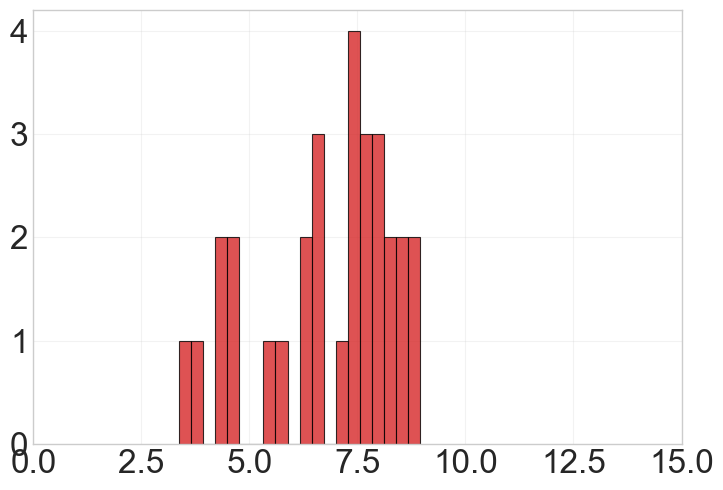

In [16]:
plot_final_val_surface_disp_rmse_histogram(
    rollout_zarr_path="FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr",
    bins=20,
    color="tab:red",
    alpha=0.8,
    ref_value=None,
    ref_label=None,
    show_median=False,
    show_mean=False,
    xlim=(0,15),
    save_path="Model_A_final_u_rollouts_rmse.png",
    infer_support_time_from_global_max_t=True
)

Model: ag
Evaluating RMSE only for simulations with support at t = 98.000000
Number of sims used      : 30
Number skipped (support) : 155
Number skipped (invalid) : 0
Mean RMSE                : 5.544557
Median RMSE              : 5.821345
Std RMSE                 : 2.108909
10th percentile          : 2.773457
90th percentile          : 7.848920
Min RMSE                 : 1.735626
Max RMSE                 : 10.721738


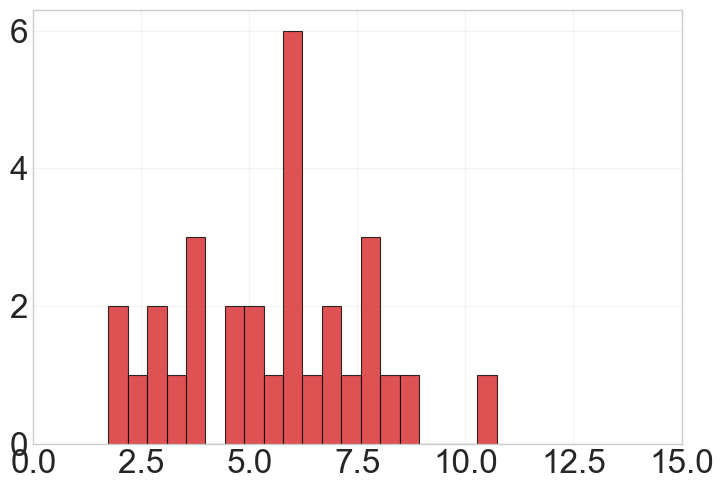

In [10]:
plot_final_val_surface_disp_rmse_histogram(
    rollout_zarr_path="FINAL_models/Model_B/Model_B_Ag_val_rollouts_r9.zarr",
    bins=20,
    color="tab:red",
    alpha=0.8,
    ref_value=None,
    ref_label=None,
    show_median=False,
    show_mean=False,
    xlim=(0,15),
    save_path="Model_B_final_u_rollouts_rmse.png",
    infer_support_time_from_global_max_t=True

)


Model: pca
Evaluating RMSE only for simulations with support at t = 98.000000
Number of sims used      : 30
Number skipped (support) : 155
Number skipped (invalid) : 0
Mean RMSE                : 4.390776
Median RMSE              : 3.145210
Std RMSE                 : 3.308729
10th percentile          : 1.896740
90th percentile          : 8.846492
Min RMSE                 : 1.705083
Max RMSE                 : 14.214500


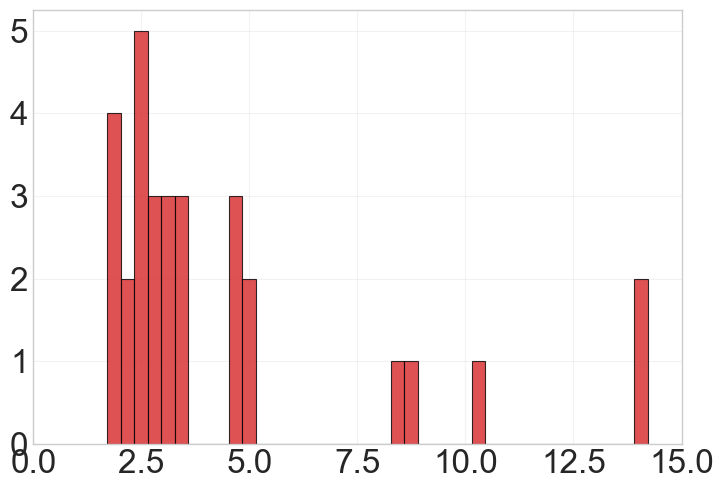

In [15]:
plot_final_val_surface_disp_rmse_histogram(
    rollout_zarr_path="FINAL_models/Model_C/Model_C_pca_val_rollouts_r9.zarr",
    bins=40,
    color="tab:red",
    alpha=0.8,
    ref_value=None,
    ref_label=None,
    show_median=False,
    show_mean=False,
    xlim=(0,15),
    save_path="Model_C_final_u_rollouts_rmse.png",
    infer_support_time_from_global_max_t=True
    
)

Model: cnn
Evaluating RMSE only for simulations with support at t = 98.000000
Number of sims used      : 30
Number skipped (support) : 155
Number skipped (invalid) : 0
Mean RMSE                : 1.084154
Median RMSE              : 0.836258
Std RMSE                 : 0.941756
10th percentile          : 0.528646
90th percentile          : 1.707560
Min RMSE                 : 0.312438
Max RMSE                 : 5.509896


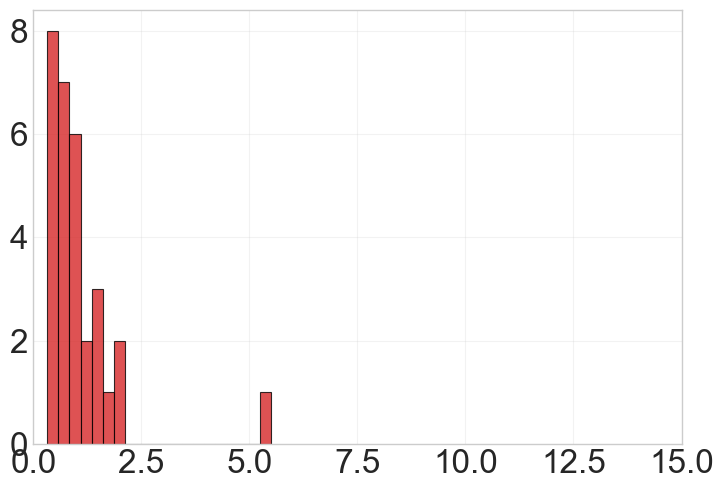

In [13]:
plot_final_val_surface_disp_rmse_histogram(
    rollout_zarr_path="FINAL_models/Model_D/Model_D_cnn_val_rollouts_r9.zarr",
    bins=20,
    color="tab:red",
    alpha=0.8,
    ref_value=None,
    ref_label=None,
    show_median=False,
    show_mean=False,
    xlim=(0,15),
    save_path="Model_D_final_u_rollouts_rmse.png",
    infer_support_time_from_global_max_t=True


)

In [20]:
# Cell 1
import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [21]:
# Cell 2: paths and loading
zarr_path = Path("expd_volumes.zarr")

cvol = np.asarray(zarr.open(str(zarr_path / "expander_volume" / "cvol"), mode="r"))

# try to load times from the top-level "times" entry
times = np.asarray(zarr.open(str(zarr_path / "expander_volume"/ "times"), mode="r"))

print("cvol shape :", cvol.shape)
print("times shape:", times.shape)

cvol shape : (42237,)
times shape: (42237,)


In [22]:
# Cell 3: find boundaries where time decreases
dt = np.diff(times)

# indices i where times[i+1] < times[i]
reset_idx = np.where(dt < 0)[0]

print("Number of detected resets:", len(reset_idx))
print("Expected number of simulations:", len(reset_idx) + 1)
print("First few reset indices:", reset_idx[:10])

Number of detected resets: 926
Expected number of simulations: 927
First few reset indices: [ 68 129 190 221 252 293 314 383 452 513]


In [23]:
# Cell 4: convert reset indices into segment start/end indices
starts = np.r_[0, reset_idx + 1]
ends   = np.r_[reset_idx + 1, len(times)]

print("Number of profiles found:", len(starts))
print("First 10 segment lengths:", (ends - starts)[:10])

# quick sanity check
assert len(starts) == len(ends)
assert ends[-1] == len(times)
assert np.all(ends > starts)

Number of profiles found: 927
First 10 segment lengths: [69 61 61 31 31 41 21 69 69 61]


In [24]:
# Cell 5: split into per-simulation lists
time_profiles = [times[s:e] for s, e in zip(starts, ends)]
cvol_profiles = [cvol[s:e]   for s, e in zip(starts, ends)]

print("Number of extracted profiles:", len(cvol_profiles))
print("Lengths of first 10 profiles:", [len(x) for x in cvol_profiles[:10]])
print("Total number of snapshots recovered:", sum(len(x) for x in cvol_profiles))

Number of extracted profiles: 927
Lengths of first 10 profiles: [69, 61, 61, 31, 31, 41, 21, 69, 69, 61]
Total number of snapshots recovered: 42237


In [25]:
# Cell 6
expected_n_sims = 927
print("Found profiles:", len(cvol_profiles))
print("Expected      :", expected_n_sims)

if len(cvol_profiles) != expected_n_sims:
    print("WARNING: detected number of profiles does not match expected count.")

Found profiles: 927
Expected      : 927


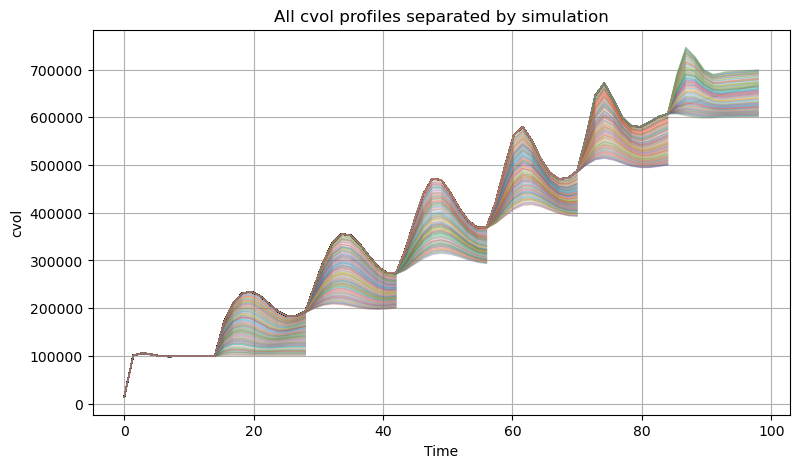

In [26]:
# Cell 7: plot all cvol curves against their own time axes
plt.figure(figsize=(9, 5))

for t_prof, c_prof in zip(time_profiles, cvol_profiles):
    plt.plot(t_prof, c_prof, linewidth=0.8, alpha=0.25)

plt.xlabel("Time")
plt.ylabel("cvol")
plt.title("All cvol profiles separated by simulation")
plt.grid(True)
plt.show()

Skipping L=63: no eligible sampled curves


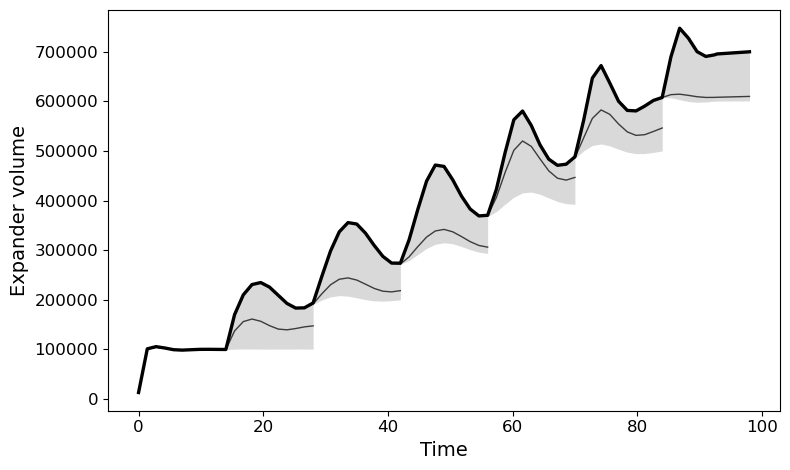

Random sampled curve chosen in each band:
  length group L= 21 -> local_idx=5
  length group L= 31 -> local_idx=107
  length group L= 41 -> local_idx=63
  length group L= 51 -> local_idx=100
  length group L= 61 -> local_idx=40
  length group L= 69 -> local_idx=19


In [67]:
# Cell 8: shaded support bands + one random sampled curve per band
# excluding the offending curve (L=63, local_idx=0) + global max in black
# plotted against real time instead of local step number

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.0, 4.8))

# ----------------------------------------------------------
# Group trajectories by their profile length
# ----------------------------------------------------------
lengths = np.array([len(c_prof) for c_prof in cvol_profiles])
unique_lengths = np.array(sorted(np.unique(lengths)))

profiles_by_length = {
    L: [c_prof for c_prof in cvol_profiles if len(c_prof) == L]
    for L in unique_lengths
}

time_profiles_by_length = {
    L: [t_prof for t_prof, c_prof in zip(time_profiles, cvol_profiles) if len(c_prof) == L]
    for L in unique_lengths
}

# ----------------------------------------------------------
# Offending curve to exclude from random sampling
# ----------------------------------------------------------
bad_L = 63
bad_local_idx = 0

# ----------------------------------------------------------
# Draw a filled min-max band for each length group
# ----------------------------------------------------------
band_color = "0.85"
band_alpha = 1.0

for L in unique_lengths:
    group = profiles_by_length[L]
    t_group = time_profiles_by_length[L]

    Y = np.vstack(group)
    T = np.asarray(t_group[0])   # assumes common time grid within each length group

    y_min = np.min(Y, axis=0)
    y_max = np.max(Y, axis=0)

    ax.fill_between(
        T,
        y_min,
        y_max,
        color=band_color,
        alpha=band_alpha,
        linewidth=0,
        zorder=1
    )

# ----------------------------------------------------------
# Overlay one random sampled curve per band
# ----------------------------------------------------------
rng = np.random.default_rng(23)

sample_color = "0.20"
sample_lw = 1.0
sample_alpha = 0.95

sampled_info = []

for L in unique_lengths:
    group = profiles_by_length[L]
    t_group = time_profiles_by_length[L]

    eligible_idx = np.arange(len(group))

    if L == bad_L:
        eligible_idx = eligible_idx[eligible_idx != bad_local_idx]

    if len(eligible_idx) == 0:
        print(f"Skipping L={L}: no eligible sampled curves")
        continue

    rep_local_idx = rng.choice(eligible_idx)
    c_rep = group[rep_local_idx]
    t_rep = np.asarray(t_group[rep_local_idx])

    ax.plot(
        t_rep,
        c_rep,
        color=sample_color,
        linewidth=sample_lw,
        alpha=sample_alpha,
        zorder=2
    )

    sampled_info.append((L, rep_local_idx))

# ----------------------------------------------------------
# Overlay the global max curve in black
# ----------------------------------------------------------
top_idx = np.argmax([np.max(c_prof) for c_prof in cvol_profiles])
c_top = cvol_profiles[top_idx]
t_top = np.asarray(time_profiles[top_idx])

ax.plot(
    t_top,
    c_top,
    color="black",
    linewidth=2.4,
    alpha=1.0,
    zorder=3
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Expander volume", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

fig.tight_layout()
plt.savefig("sampled_vol_traj_vs_time.png", dpi=600)
plt.show()

# ----------------------------------------------------------
# Print which random curve was sampled in each band
# ----------------------------------------------------------
print("Random sampled curve chosen in each band:")
for L, idx in sampled_info:
    print(f"  length group L={L:3d} -> local_idx={idx}")

In [39]:
# Cell 8a: reproduce the random sampling and keep track of selections
import numpy as np
import matplotlib.pyplot as plt

lengths = np.array([len(c_prof) for c_prof in cvol_profiles])
unique_lengths = np.array(sorted(np.unique(lengths)))

profiles_by_length = {
    L: [c_prof for c_prof in cvol_profiles if len(c_prof) == L]
    for L in unique_lengths
}

rng = np.random.default_rng(412)
n_sample_per_zone = 2

sampled_info = []  # store (L, local_idx, curve)

for L in unique_lengths:
    group = profiles_by_length[L]
    n_group = len(group)

    sample_idx = rng.choice(
        n_group,
        size=min(n_sample_per_zone, n_group),
        replace=False
    )

    for idx in sample_idx:
        sampled_info.append((L, idx, group[idx]))

print("Sampled curves:")
for L, idx, _ in sampled_info:
    print(f"  length={L}, local_idx={idx}")

Sampled curves:
  length=21, local_idx=134
  length=21, local_idx=110
  length=31, local_idx=132
  length=31, local_idx=77
  length=41, local_idx=11
  length=41, local_idx=16
  length=51, local_idx=100
  length=51, local_idx=144
  length=61, local_idx=98
  length=61, local_idx=103
  length=63, local_idx=0
  length=69, local_idx=4
  length=69, local_idx=73


In [66]:
# Times for the longest length group
Lmax = max(unique_lengths)
group_idx_longest = [i for i, c in enumerate(cvol_profiles) if len(c) == Lmax]

print("Longest length group Lmax =", Lmax)
print("Number of profiles in longest group =", len(group_idx_longest))

# Show the time vector for the first profile in that group
i0 = group_idx_longest[0]
t_longest = time_profiles[i0]

print("Times for one longest-group profile:")
print(t_longest)

print("\nStep -> time")
for step, t in enumerate(t_longest, start=1):   # step numbering starts at 1
    print(f"step {step:2d} -> time {t}")

Longest length group Lmax = 69
Number of profiles in longest group = 151
Times for one longest-group profile:
[ 0.   1.4  2.8  4.2  5.6  7.   8.4  9.8 11.2 12.6 14.  15.4 16.8 18.2
 19.6 21.  22.4 23.8 25.2 26.6 28.  29.4 30.8 32.2 33.6 35.  36.4 37.8
 39.2 40.6 42.  43.4 44.8 46.2 47.6 49.  50.4 51.8 53.2 54.6 56.  57.4
 58.8 60.2 61.6 63.  64.4 65.8 67.2 68.6 70.  71.4 72.8 74.2 75.6 77.
 78.4 79.8 81.2 82.6 84.  85.4 86.8 88.2 89.6 91.  92.4 92.8 98. ]

Step -> time
step  1 -> time 0.0
step  2 -> time 1.399999976158142
step  3 -> time 2.799999952316284
step  4 -> time 4.199999809265137
step  5 -> time 5.599999904632568
step  6 -> time 7.0
step  7 -> time 8.399999618530273
step  8 -> time 9.800000190734863
step  9 -> time 11.199999809265137
step 10 -> time 12.600000381469727
step 11 -> time 14.0
step 12 -> time 15.399999618530273
step 13 -> time 16.799999237060547
step 14 -> time 18.200000762939453
step 15 -> time 19.600000381469727
step 16 -> time 21.0
step 17 -> time 22.39999961853

In [64]:
# Number of steps in the longest length group
Lmax = max(unique_lengths)
print("Longest length group (number of steps):", Lmax)

Longest length group (number of steps): 69


Longest profile length: 69
Sampled curves in longest group:
  local_idx = 4
  local_idx = 73


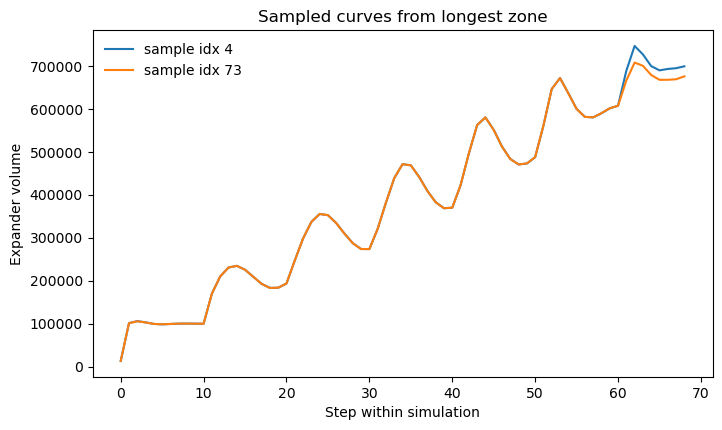

In [40]:
# Cell 8b: inspect sampled curves from the longest zone
Lmax = unique_lengths[-1]
print("Longest profile length:", Lmax)

longest_group = profiles_by_length[Lmax]
sampled_longest = [(L, idx, c) for (L, idx, c) in sampled_info if L == Lmax]

print("Sampled curves in longest group:")
for _, idx, _ in sampled_longest:
    print("  local_idx =", idx)

plt.figure(figsize=(8, 4.5))
for _, idx, c in sampled_longest:
    plt.plot(np.arange(len(c)), c, linewidth=1.5, label=f"sample idx {idx}")

plt.xlabel("Step within simulation")
plt.ylabel("Expander volume")
plt.title("Sampled curves from longest zone")
plt.legend(frameon=False)
plt.grid(False)
plt.show()

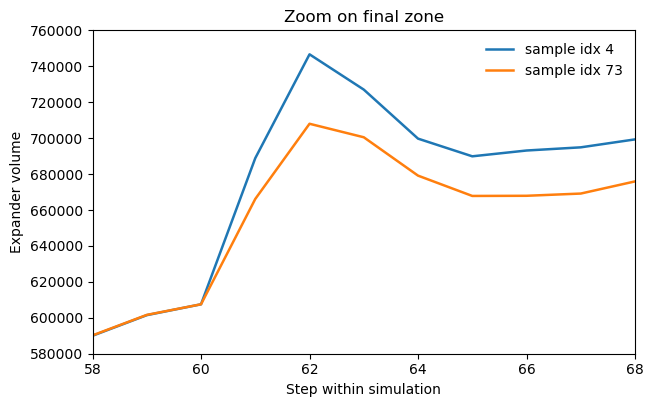

In [41]:
# Cell 8c: zoom near the final zone
plt.figure(figsize=(7, 4.2))
for _, idx, c in sampled_longest:
    plt.plot(np.arange(len(c)), c, linewidth=1.8, label=f"sample idx {idx}")

plt.xlim(58, Lmax - 1)
plt.ylim(580000, 760000)
plt.xlabel("Step within simulation")
plt.ylabel("Expander volume")
plt.title("Zoom on final zone")
plt.legend(frameon=False)
plt.grid(False)
plt.show()

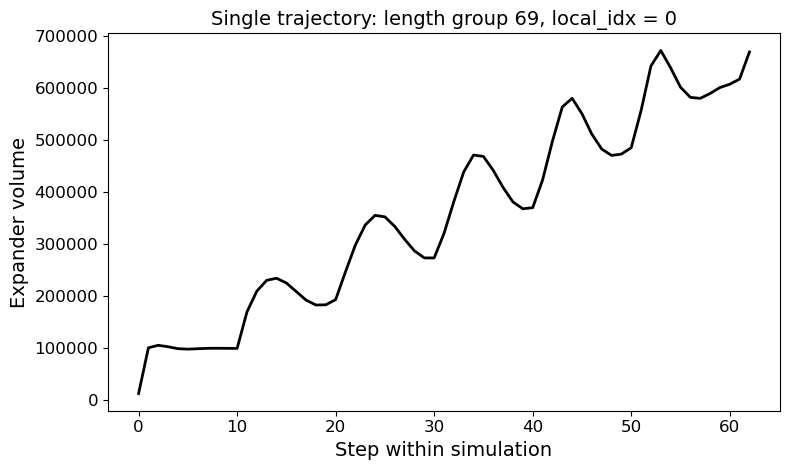

In [52]:
# Plot local_idx = 0 from the longest profile-length group by itself
import numpy as np
import matplotlib.pyplot as plt

L_target = 63
group = profiles_by_length[L_target]
c0 = group[0]
x0 = np.arange(len(c0))

plt.figure(figsize=(8.0, 4.8))
plt.plot(x0, c0, color="black", linewidth=2.0)

plt.xlabel("Step within simulation", fontsize=14)
plt.ylabel("Expander volume", fontsize=14)
plt.title(f"Single trajectory: length group {L_target}, local_idx = 0", fontsize=14)
plt.tick_params(axis="both", labelsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

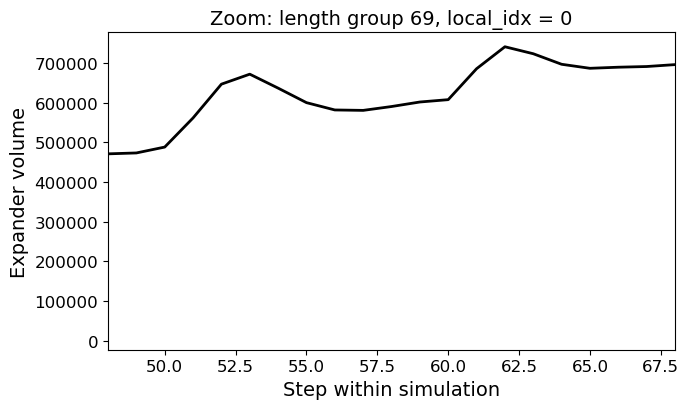

In [50]:
# Zoomed view of local_idx = 0
plt.figure(figsize=(7.0, 4.2))
plt.plot(x0, c0, color="black", linewidth=2.0)

plt.xlim(48, len(c0) - 1)   # adjust as needed
plt.xlabel("Step within simulation", fontsize=14)
plt.ylabel("Expander volume", fontsize=14)
plt.title(f"Zoom: length group {Lmax}, local_idx = 0", fontsize=14)
plt.tick_params(axis="both", labelsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

In [42]:
# Cell 8g: investigate abrupt entry into the previous volume stage
Lmax = unique_lengths[-1]
longest_group = profiles_by_length[Lmax]

prev_stage_entry = 52   # adjust if needed
prev_stage_end   = 61   # optional, just for plotting/inspection

jumps_prev = []
for i, c in enumerate(longest_group):
    if len(c) > prev_stage_entry:
        jump = c[prev_stage_entry] - c[prev_stage_entry - 1]
        jumps_prev.append((i, jump, c[-1], np.max(c)))

# sort by largest jump into this stage
jumps_prev_sorted = sorted(jumps_prev, key=lambda t: t[1], reverse=True)

print("Top 10 largest entry jumps into the previous volume stage:")
for i, jump, final_val, max_val in jumps_prev_sorted[:10]:
    print(f"idx={i:4d}, jump={jump:10.3f}, final={final_val:10.3f}, max={max_val:10.3f}")

Top 10 largest entry jumps into the previous volume stage:
idx= 139, jump= 85512.688, final=681640.062, max=717310.250
idx=  15, jump= 85486.062, final=617083.375, max=672498.375
idx=  85, jump= 85476.875, final=606635.688, max=672408.250
idx= 120, jump= 85474.188, final=603587.188, max=672427.375
idx=  23, jump= 85463.750, final=668581.500, max=696342.500
idx= 118, jump= 85449.000, final=679451.688, max=713784.812
idx=   7, jump= 85432.750, final=631839.312, max=672463.688
idx=  16, jump= 85417.500, final=612003.500, max=672238.438
idx=  66, jump= 85414.688, final=697421.625, max=743605.812
idx=  39, jump= 85406.188, final=667231.875, max=694235.188


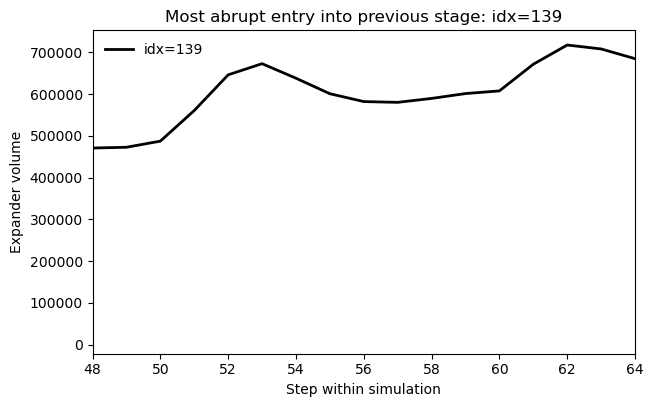

Values around previous-stage entry:
k=48, cvol=470639.969
k=49, cvol=472448.938
k=50, cvol=487139.750
k=51, cvol=560388.125
k=52, cvol=645900.812
k=53, cvol=672629.000
k=54, cvol=637806.750
k=55, cvol=600692.062
k=56, cvol=581872.000
k=57, cvol=580029.688
k=58, cvol=589426.562
k=59, cvol=601068.688
k=60, cvol=607474.000
k=61, cvol=671266.438
k=62, cvol=717310.250
k=63, cvol=707900.062


In [43]:
# Cell 8h: plot the single most suspicious curve for the previous stage
worst_prev_idx = jumps_prev_sorted[0][0]
c_bad_prev = longest_group[worst_prev_idx]

plt.figure(figsize=(7, 4.2))
plt.plot(np.arange(len(c_bad_prev)), c_bad_prev, color="black", linewidth=2, label=f"idx={worst_prev_idx}")
plt.xlim(48, 64)
plt.xlabel("Step within simulation")
plt.ylabel("Expander volume")
plt.title(f"Most abrupt entry into previous stage: idx={worst_prev_idx}")
plt.grid(False)
plt.legend(frameon=False)
plt.show()

print("Values around previous-stage entry:")
for k in range(48, min(len(c_bad_prev), 64)):
    print(f"k={k:2d}, cvol={c_bad_prev[k]:.3f}")

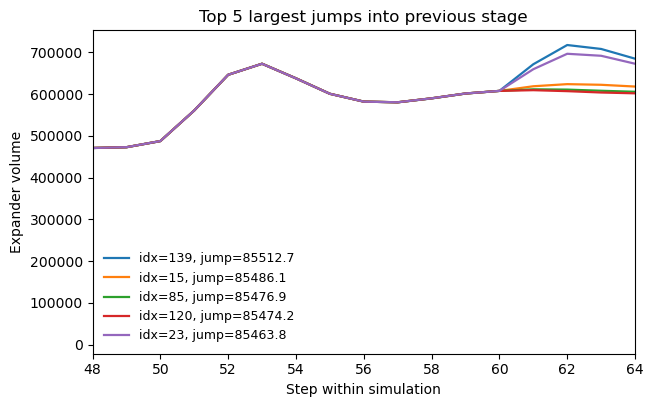

In [44]:
# Cell 8i: compare the top few suspicious curves for the previous stage
plt.figure(figsize=(7, 4.2))

for i, jump, _, _ in jumps_prev_sorted[:5]:
    c = longest_group[i]
    plt.plot(np.arange(len(c)), c, linewidth=1.6, label=f"idx={i}, jump={jump:.1f}")

plt.xlim(48, 64)
plt.xlabel("Step within simulation")
plt.ylabel("Expander volume")
plt.title("Top 5 largest jumps into previous stage")
plt.grid(False)
plt.legend(frameon=False, fontsize=9)
plt.show()

In [28]:
# Cell 9: validate segmentation
bad_profiles = []

for i, t_prof in enumerate(time_profiles):
    if np.any(np.diff(t_prof) < 0):
        bad_profiles.append(i)

print("Profiles with internal time decreases:", len(bad_profiles))
if bad_profiles:
    print("First few bad profile indices:", bad_profiles[:10])

Profiles with internal time decreases: 0


Min profile length : 21
Max profile length : 69
Mean profile length: 45.56310679611651


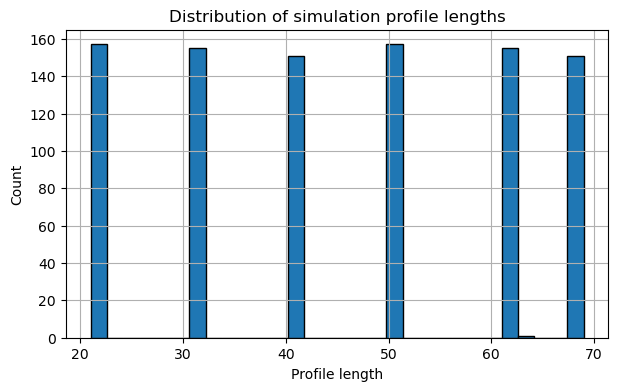

In [29]:
# Cell 10
lengths = np.array([len(x) for x in cvol_profiles])

print("Min profile length :", lengths.min())
print("Max profile length :", lengths.max())
print("Mean profile length:", lengths.mean())

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=30, edgecolor="black")
plt.xlabel("Profile length")
plt.ylabel("Count")
plt.title("Distribution of simulation profile lengths")
plt.grid(True)
plt.show()